In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("cars_data_clean.csv")

print("========== DATASET LOADED ==========")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
display(df.head())

========== DATASET LOADED ==========
Rows    : 37813
Columns : 66


,usedCarSkuId,loc,myear,body,transmission,fuel,km,ip,images,imgCount,...,Fuel Suppy System,Compression Ratio,Alloy Wheel Size,Ground Clearance Unladen,Max Power Delivered,Max Power At,Max Torque Delivered,Max Torque At,Bore,Stroke
0,7111bf25-97af-47f9-867b-40879190d800,gomti nagar,2016,hatchback,manual,cng,69162.0,0,[{'img': 'https://images10.gaadi.com/usedcar_i...,15,...,NaN,NaN,NaN,NaN,58.16,6200.0,77.0,3500.0,69.0,NaN
1,c309efc1-efaf-4f82-81ad-dcb38eb36665,borivali west,2015,hatchback,manual,cng,45864.0,0,[{'img': 'https://images10.gaadi.com/usedcar_i...,15,...,Gasoline Port Injection,11.0,NaN,NaN,58.20,6000.0,78.0,3500.0,73.0,NaN
2,7609f710-0c97-4f00-9a47-9b9284b62d3a,jasola,2015,sedan,manual,cng,81506.0,0,[{'img': 'https://images10.gaadi.com/usedcar_i...,15,...,NaN,NaN,NaN,NaN,86.70,6000.0,109.0,4500.0,NaN,NaN
3,278b76e3-5539-4a5e-ae3e-353a2e3b6d7d,jasola,2013,hatchback,manual,cng,115893.0,0,[{'img': ''}],0,...,Multi-Point Fuel Injection,NaN,13.0,NaN,58.20,6200.0,77.0,3500.0,NaN,NaN
4,b1eab99b-a606-48dd-a75b-57feb8a9ad92,mumbai g.p.o.,2022,muv,manual,cng,18900.0,0,[{'img': 'https://images10.gaadi.com/usedcar_i...,6,...,NaN,12.0,NaN,NaN,86.63,5500.0,121.5,4200.0,NaN,NaN


In [3]:
required_columns = [
    "myear",
    "body",
    "transmission",
    "fuel",
    "km",
    "owner_type",
    "listed_price"
]

car_df = df[required_columns].copy()

print("========== SELECTED FEATURES ==========")
display(car_df.head())
print("Shape:", car_df.shape)

========== SELECTED FEATURES ==========


,myear,body,transmission,fuel,km,owner_type,listed_price
0,2016,hatchback,manual,cng,69162.0,first,370000.0
1,2015,hatchback,manual,cng,45864.0,first,365000.0
2,2015,sedan,manual,cng,81506.0,second,421000.0
3,2013,hatchback,manual,cng,115893.0,second,240000.0
4,2022,muv,manual,cng,18900.0,first,1175000.0


Shape: (37813, 7)


In [4]:
print("Missing Values Before Cleaning:")
display(car_df.isnull().sum().to_frame("Missing Values"))

car_df = car_df.dropna()
car_df = car_df.drop_duplicates()

print("Shape After Cleaning:", car_df.shape)
display(car_df.isnull().sum().to_frame("Missing Values"))

Missing Values Before Cleaning:


,Missing Values
myear,0
body,19
transmission,0
fuel,0
km,0
owner_type,0
listed_price,0


Shape After Cleaning: (37431, 7)


,Missing Values
myear,0
body,0
transmission,0
fuel,0
km,0
owner_type,0
listed_price,0


In [5]:
display(car_df.describe().round(2))

,myear,km,listed_price
count,37431.00,37431.00,3.743100e+04
mean,2015.57,62497.83,7.972732e+05
std,3.78,58669.18,3.050635e+06
min,1983.00,101.00,1.196300e+04
25%,2013.00,31800.00,3.190305e+05
50%,2016.00,56811.00,5.250000e+05
75%,2018.00,83402.00,8.532395e+05
max,2023.00,6300000.00,5.500006e+08


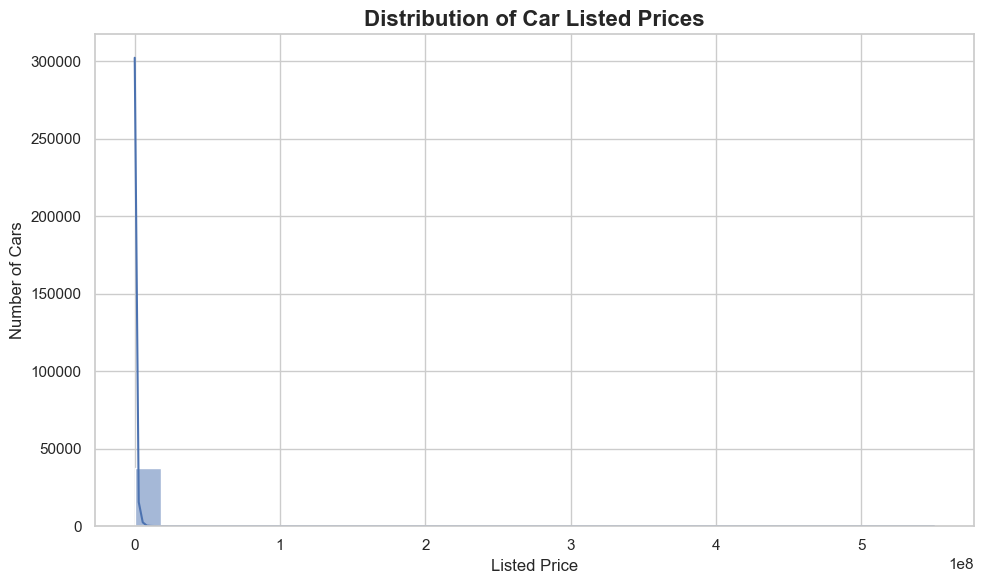

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(car_df["listed_price"], bins=30, kde=True)
plt.title("Distribution of Car Listed Prices", fontsize=16, fontweight="bold")
plt.xlabel("Listed Price")
plt.ylabel("Number of Cars")
plt.tight_layout()
plt.show()

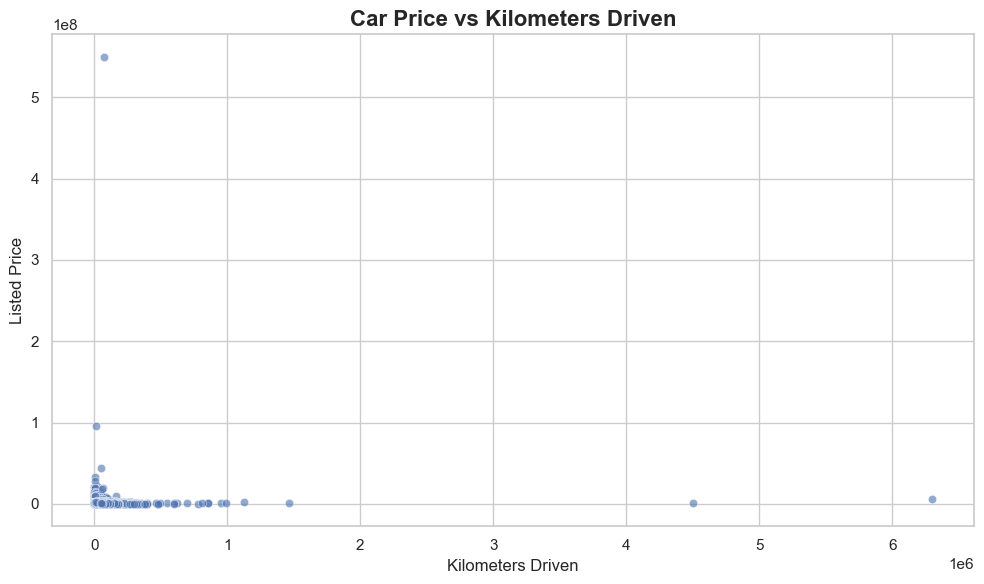

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=car_df, x="km", y="listed_price", alpha=0.6)
plt.title("Car Price vs Kilometers Driven", fontsize=16, fontweight="bold")
plt.xlabel("Kilometers Driven")
plt.ylabel("Listed Price")
plt.tight_layout()
plt.show()

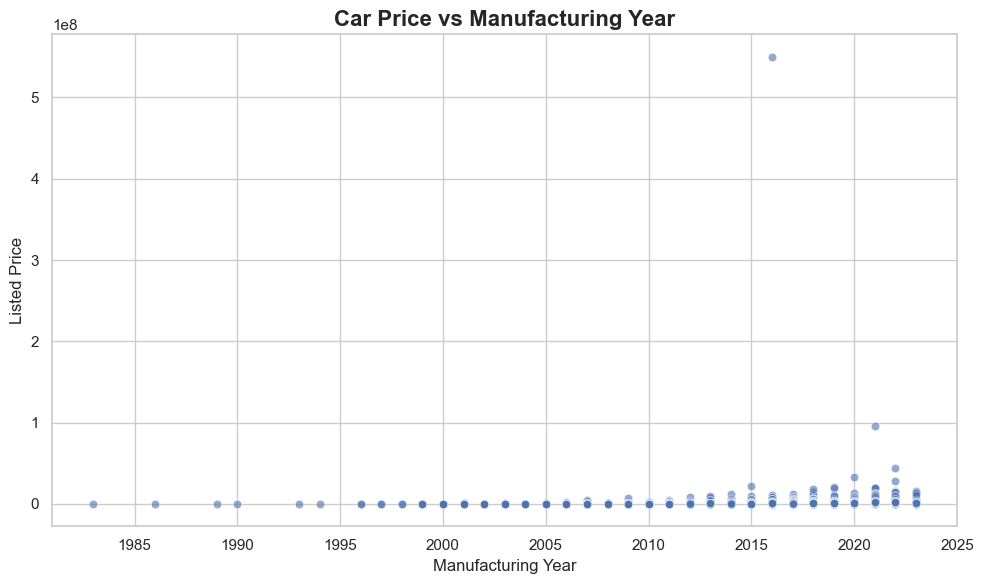

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=car_df, x="myear", y="listed_price", alpha=0.6)
plt.title("Car Price vs Manufacturing Year", fontsize=16, fontweight="bold")
plt.xlabel("Manufacturing Year")
plt.ylabel("Listed Price")
plt.tight_layout()
plt.show()

In [9]:
categorical_columns = ["body", "transmission", "fuel", "owner_type"]
encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()
    car_df[column] = encoder.fit_transform(car_df[column].astype(str))
    encoders[column] = encoder

display(car_df.head())

,myear,body,transmission,fuel,km,owner_type,listed_price
0,2016,2,1,0,69162.0,1,370000.0
1,2015,2,1,0,45864.0,1,365000.0
2,2015,8,1,0,81506.0,3,421000.0
3,2013,2,1,0,115893.0,3,240000.0
4,2022,6,1,0,18900.0,1,1175000.0


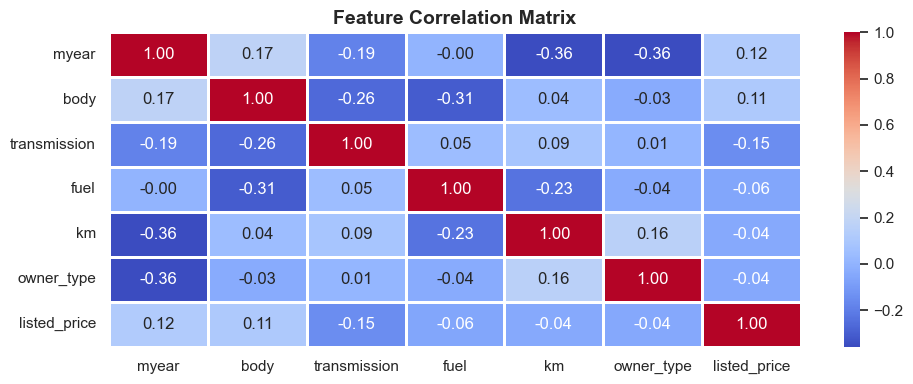

In [10]:
plt.figure(figsize=(10, 4))
correlation = car_df.corr()
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.8)
plt.title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [11]:
X = car_df.drop("listed_price", axis=1)
y = car_df["listed_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples: 29944
Testing Samples : 7487


In [12]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("========== LINEAR REGRESSION ==========")
print(f"R² Score : {lr_r2:.4f}")
print(f"MAE      : {lr_mae:,.2f}")
print(f"RMSE     : {lr_rmse:,.2f}")

========== LINEAR REGRESSION ==========
R² Score : 0.2966
MAE      : 382,799.39
RMSE     : 888,592.65


In [13]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("========== RANDOM FOREST ==========")
print(f"R² Score : {rf_r2:.4f}")
print(f"MAE      : {rf_mae:,.2f}")
print(f"RMSE     : {rf_rmse:,.2f}")

========== RANDOM FOREST ==========
R² Score : -5.0781
MAE      : 344,344.51
RMSE     : 2,612,086.12


In [14]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [lr_r2, rf_r2],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse]
})

display(comparison.round(4))

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.2966,382799.3921,8.885927e+05
1,Random Forest,-5.0781,344344.5061,2.612086e+06


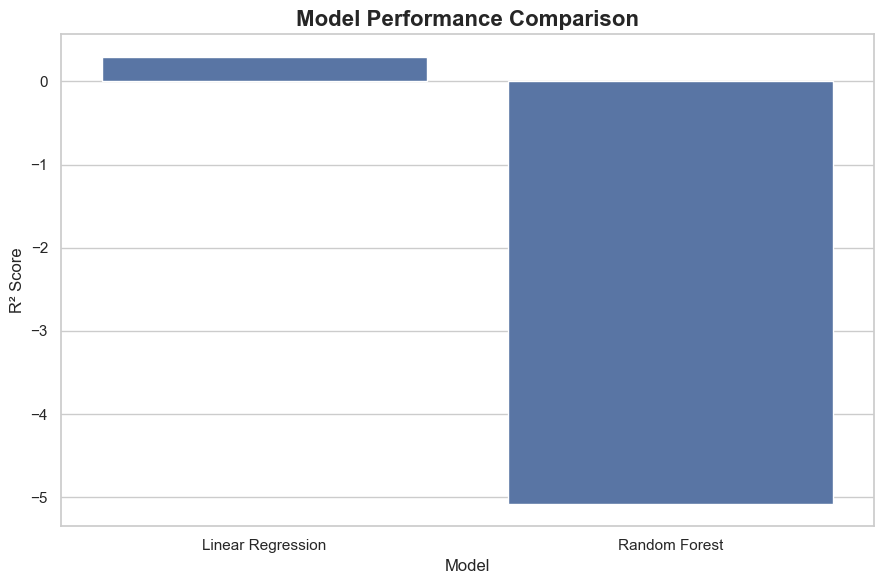

In [15]:
plt.figure(figsize=(9, 6))
sns.barplot(data=comparison, x="Model", y="R2 Score")
plt.title("Model Performance Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.tight_layout()
plt.show()

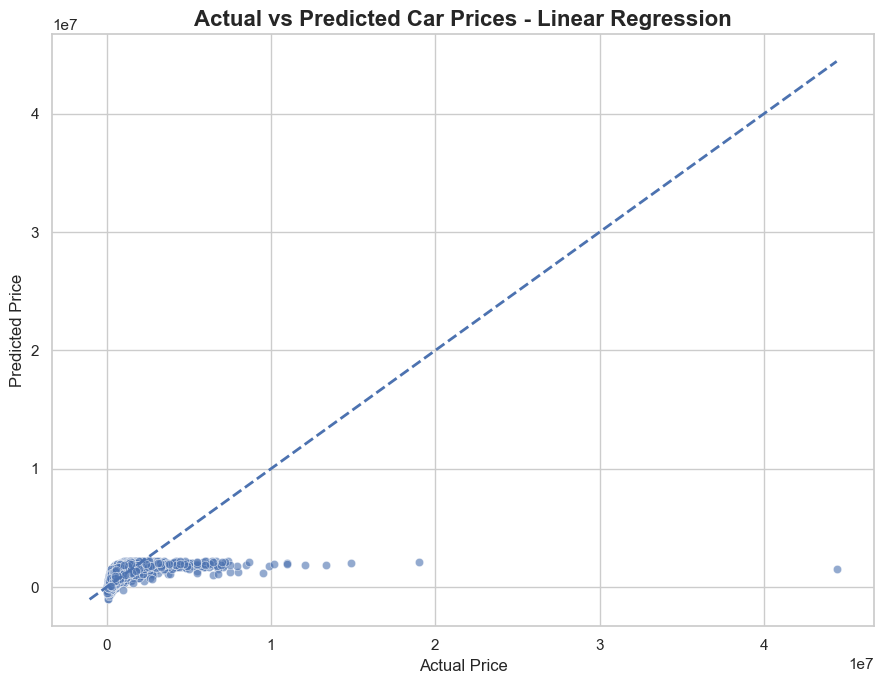

In [16]:
plt.figure(figsize=(9, 7))

sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6)

min_value = min(y_test.min(), y_pred_lr.min())
max_value = max(y_test.max(), y_pred_lr.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.title(
    "Actual vs Predicted Car Prices - Linear Regression",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.tight_layout()
plt.savefig("linear_regression_prediction.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.round(4))


,Feature,Importance
4,km,0.7223
2,transmission,0.0910
0,myear,0.0847
1,body,0.0758
3,fuel,0.0180
5,owner_type,0.0083


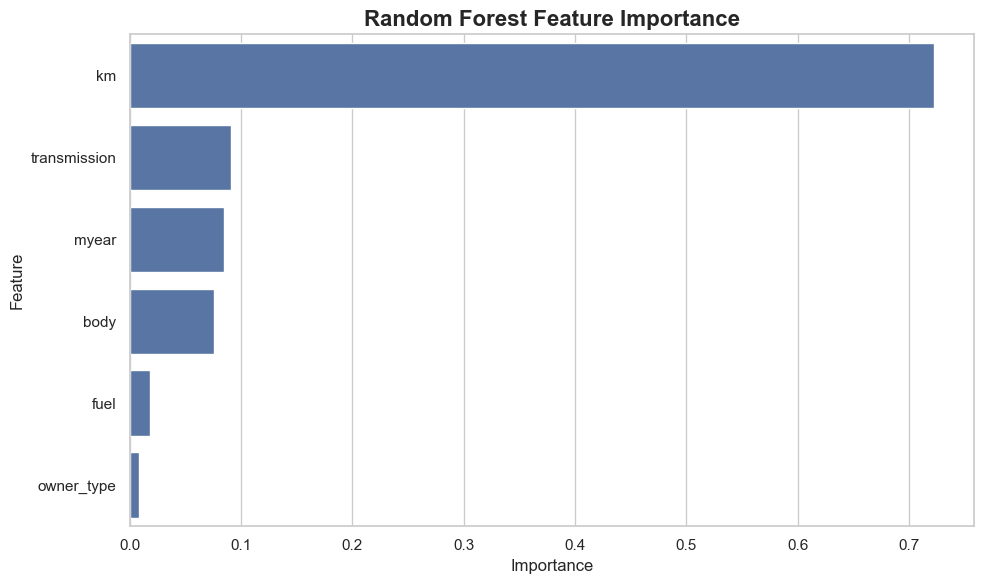

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")

In [20]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R² Score": [lr_r2, rf_r2],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse]
})

display(results.style.format({
    "R² Score": "{:.4f}",
    "MAE": "{:,.2f}",
    "RMSE": "{:,.2f}"
}))

,Model,R² Score,MAE,RMSE
0,Linear Regression,0.2966,"382,799.39","888,592.65"
1,Random Forest,-5.0781,"344,344.51","2,612,086.12"


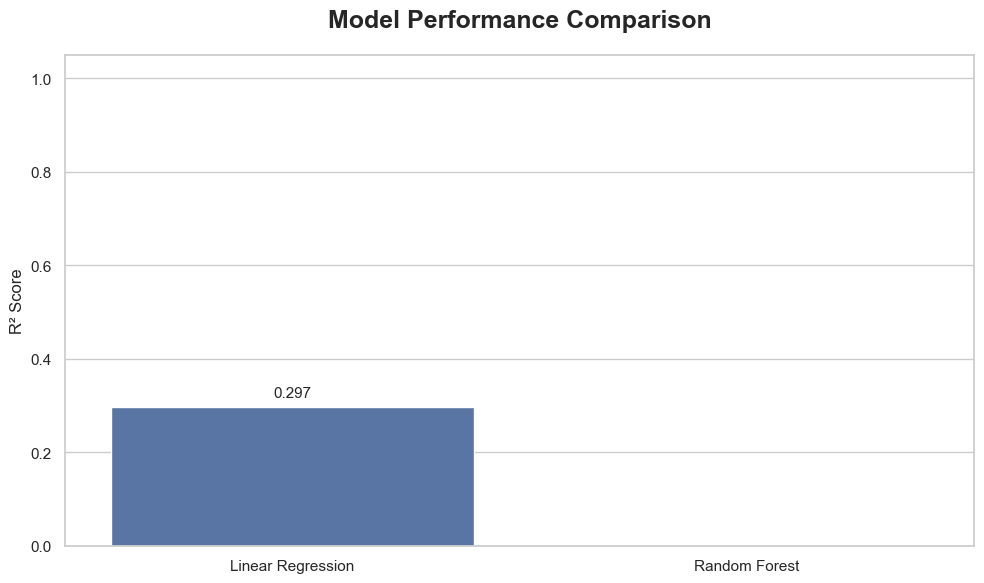

In [21]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=results,
    x="Model",
    y="R² Score"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=5, fontsize=11)

plt.title("Model Performance Comparison", fontsize=18, fontweight="bold", pad=20)
plt.xlabel("")
plt.ylabel("R² Score", fontsize=12)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

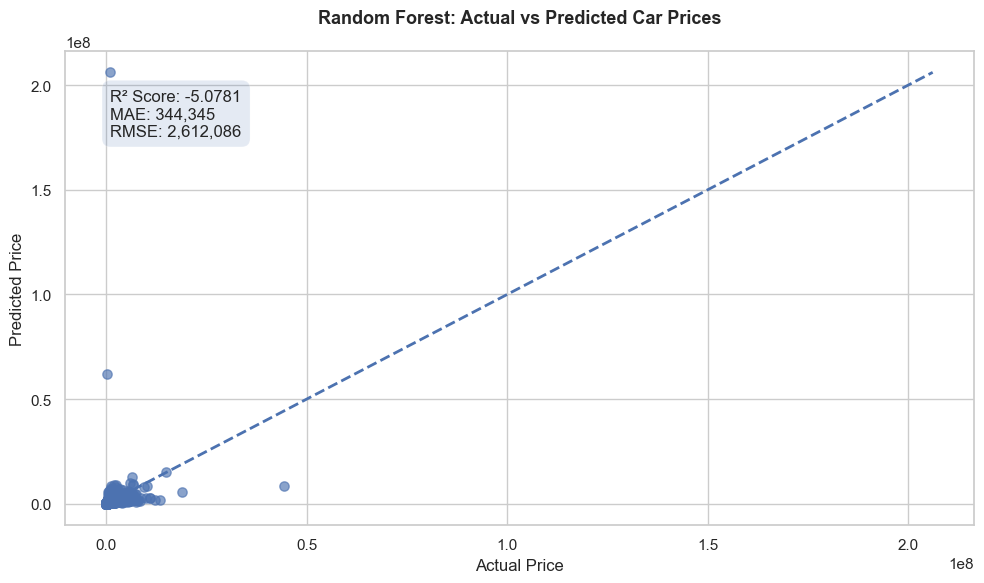

In [22]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.65,
    s=45
)

minimum = min(y_test.min(), y_pred_rf.min())
maximum = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    linewidth=2
)

plt.text(
    0.05,
    0.92,
    f"R² Score: {rf_r2:.4f}\nMAE: {rf_mae:,.0f}\nRMSE: {rf_rmse:,.0f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", alpha=0.15)
)

plt.title(
    "Random Forest: Actual vs Predicted Car Prices",
    fontsize=13,
    fontweight="bold",
    pad=20
)

plt.xlabel("Actual Price", fontsize=12)
plt.ylabel("Predicted Price", fontsize=12)

plt.tight_layout()
plt.show()

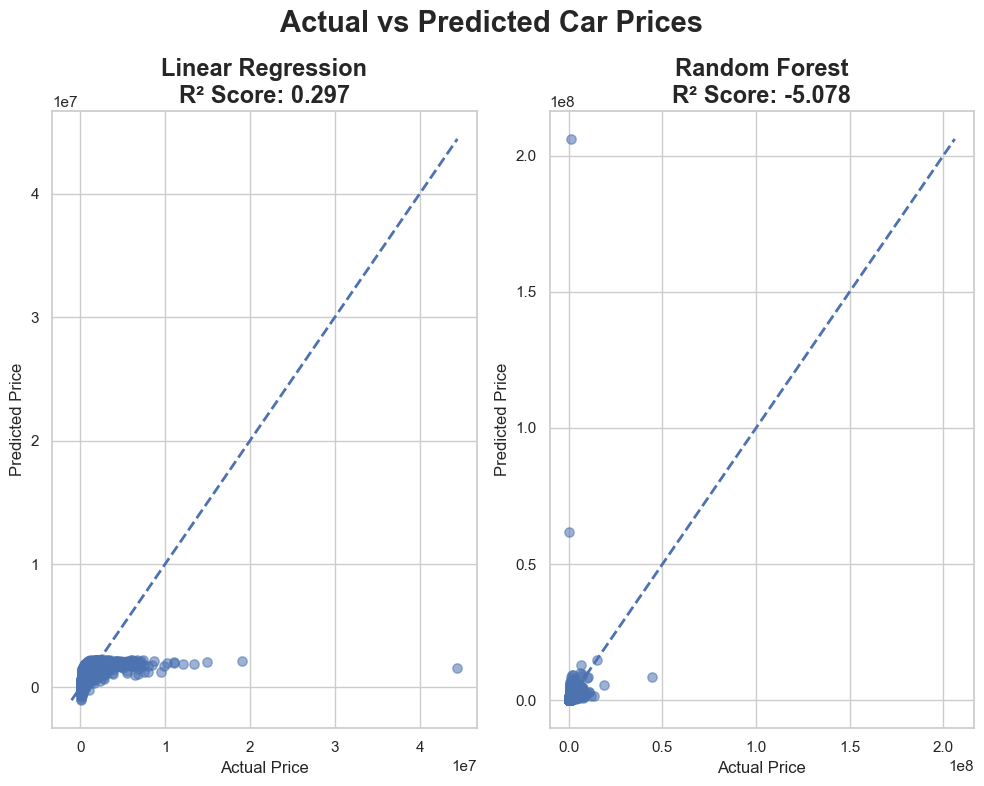

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8))

models = [
    ("Linear Regression", y_pred_lr, lr_r2),
    ("Random Forest", y_pred_rf, rf_r2)
]

for ax, (name, predictions, score) in zip(axes, models):

    ax.scatter(
        y_test,
        predictions,
        alpha=0.55,
        s=45
    )

    minimum = min(y_test.min(), predictions.min())
    maximum = max(y_test.max(), predictions.max())

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=2
    )

    ax.set_title(
        f"{name}\nR² Score: {score:.3f}",
        fontsize=17,
        fontweight="bold"
    )

    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")

plt.suptitle(
    "Actual vs Predicted Car Prices",
    fontsize=21,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

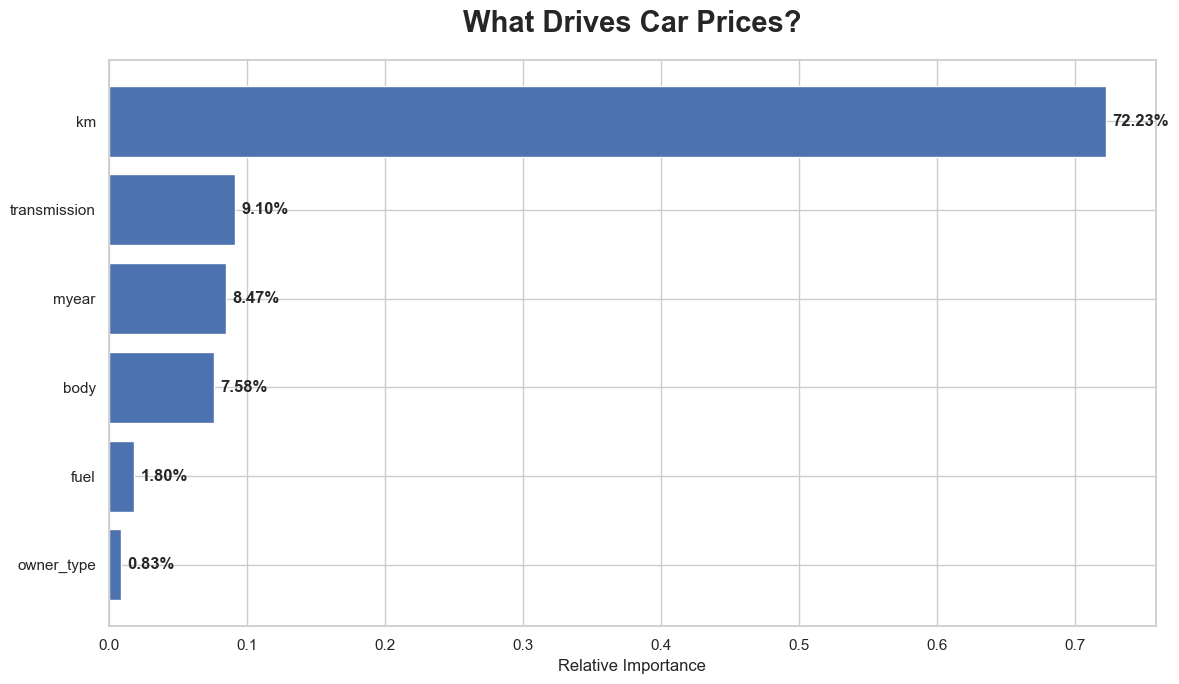

In [24]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=True
)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

ax.set_title(
    "What Drives Car Prices?",
    fontsize=21,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Relative Importance")
ax.set_ylabel("")

for bar, value in zip(
    bars,
    feature_importance["Importance"]
):
    ax.text(
        value + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2%}",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()